#Speech Separation Using Discrete Audio Tokens
Conversational AI Course

**Student:** Behnaz Dehghan
**Date:** 26th April 2026

https://github.com/Behnaz-Dehghan/Course.git

## Introduction
Speech Separation is the task of obtaining the audio of separated speakers from a mixture of speakers. It is also often known as the cocktail party problem, giving the computer ability to efficiently pay attention to audio sources in a noisy environment as humans do. Sepformer is one of the state-of-the-art models using the dual-path framework to mitigate the quadratic complexity of Transformers. Waveform-based models like Sepformer and Conv-TasNet reconstruct signals directly, where the loss is calculated based on SI-SNR (Scale-Invariant Signal-to-Noise Ratio), comparing the reconstructed and original signals.   Permutation Invariant Training (PIT) is used to handle the label ambiguity problem.

Recently, there has been a significant shift towards discretizing models using audio tokens. This is primarily because treating separation as a classification task (minimizing NLL loss) is often more stable and efficient than solving a high-variance regression problem with reconstruction loss. Furthermore, discrete tokens are naturally adaptable for integration with large-scale Multimodal LLMs. Another key advantage is robustness to noise, since the final audio is synthesized from discrete tokens, the model avoids the cumulative distortions and additive noise common in waveform-based reconstruction.

**Neural Audio Codec:** A Neural Audio Codec is a deep learning-based model discretizing continuous audio into acoustic tokens giving us a compressed, discrete representation. Unlike traditional codecs, it utilizes an Encoder-Decoder architecture with Vector Quantization bottleneck. An important aspect of codec is being low-bitrate. In this project, I used Causal versions of **FocalCodec and EnCodec** models in which each token is generated based on the information available from the current and previous time steps, not the whole signal, are designed for real-time streaming. I assume tokens generated from non-causal models might be more informative for the task.
###Recent wokrs:
TokenSplit is a generative, multi-purpose speech separation system, based on a sequence-to-sequence encoder-decoder Transformer architecture, where the encoder extracts features from the mixture and the Autoregressive decoder aligns them with the discrete sequences through cross-attention. A more recent advancement, SLM-SS, builds upon this by adding a non-autoregressive (NAR) stage in which higher-order codebooks are predicted from lower-order ones to improve decoding efficiency. However the encoder of AR transformer is pretrained wavlm, taking the mix signal and predicting the first EnCodec codebook.
##Dataset:
I used Libri2Mix[1] (train-100, dev and test sets), an open source dataset for source separation in noisy environments. It is derived from LibriSpeech signals (clean subset) and WHAM noise. To generate mixed speech based on the S1 and S2 speakers, I used the csv file of matching speakers and their own .py file with the following pipeline , but did not include Wham noise for simplicity. The mix signal is generated by performing a linear summation of clean speech sources from LibriSpeech ($Mix = S_1 + S_2$). To ensure consistency, each source was loudness-normalized using pre-defined gain factors to maintain target Signal-to-Noise Ratios (SNR). We employed the 'min' mode for sequence alignment, where mixtures are truncated to the length of the shortest utterance, ensuring full overlap throughout the sample. Finally, all signals were resampled to 16kHz to remain compatible with the FocalCodec tokenizer's input requirements.



##Implementation
###Tokenization
In the first attempt, I used EnCodec for tokenization, which produces 32-order codebooks with size|C|=1024.The most compact version is 1.5kbp producing 2 codebooks and 75 tokens per second. The challenge was how to learn multiple codebooks so it is computationally effienct and reconstructing correct outputs. For instance, AudioLM uses a hierarchical approach and trains a seperate transformer to predict higher-order codebooks conditioned on the first codebook layers.  
Another approach is taking weigted average of embeddings and use multiple output heads to generate each codebooks in parallel.
I wanted to try to sum the 2 codebook embeddings, wand implementing 2 heads in the output, which I did not have time to try.

Focal codec[3] solves this challenge by introducing a single binary codebook with lower bitrate than previous models. Compressing all acoustic information into one codebook, we need a larger codebook size. I first tried focalcodec_12_5hz with a small token rate, but codebook size 8192 seemed to be a challenge (I couldn't see any learning during trainig) since the model has to predict among a large output space. So to make it possible to train with a small dataset and small model, I chose [focalcodec_50hz_2k_causal](https://https://huggingface.co/lucadellalib/focalcodec_50hz_2k_causal), with 50hz token rate and codebook size 2048.
I generated tokens offline to avoid slow training, however it is more efficient to keep it on-the-fly while using caching to avoid multiple processes as done in focalcodec github. Using 2 seconds of audios, the encoder sequence length is 100 and decoder output is 200 after S1 and S2 concatenation. We have 13900 train samples, 3000 validation and test samples.

###Seq2Seq Autoregressive Transformer
Following the approach of TokenSplit[2], I implementeed an autoregressive transformer, similar to lab4 code in our coursework, to generate speakers’ tokens from mixed tokens. In this setup, the encoder receives the tokens corresponding to the mixed signals as input ($X = [BOS, token1,\dots,token100, EOS]$), where the $EOS$ token represents end of series and ensures the model can adapt to variable sequence lengths.
The decoder is supposed to generate single speaker tokens in series using Serialized Output Training (SOT), where the target sequence is formed by concatenating individual speaker streams separated by a special token.
$Y = [BOS, S_1 tokens, SEP, S_2 tokens, EOS]$

**Cross-entropy** on tokens is used as the loss function, encouraging the decoder to learn the joint distribution of both speaker streams in a single serialized pass.

For inference greedy and beam search(top-3) are implemented.


Typically, separation models are trained with a permutation invariant training loss function(PIT). Here,we do not need that,
since teacher-forcing during training is dictating the decoder what to generate first. During inference,we sample the first token with
model provided probabilities and this sample most likely decides which source is decoded first.[2] However, if we are generating S1 and S2 in parallel using multiple heads, PIT is defenitely needed, as done FocalCodec. Although not effective, I included that in the loss function and sum CE of S1 tokens and CE of S2 and gave less weight to structeral <sep> and <eos> tokens.

$$L_{PIT} = \min(L(S_1, \hat{S}_1) + L(S_2, \hat{S}_2), L(S_1, \hat{S}_2) + L(S_2, \hat{S}_1))$$

###Results:

Overfitting test:
```

Overfitting test: for 100 samples
Total Parameters: 7,891,972
Namespace(batch_size=64, lr=0.001, epochs=50, d_model=256, nhead=8, num_layers=2, dim_ff=1024, tokenizer='focal')
Epoch [20/200] | Loss: 6.0790 | Batch Acc: 44.63%
Epoch [40/200] | Loss: 2.8996 | Batch Acc: 93.59%
Epoch [60/200] | Loss: 1.4352 | Batch Acc: 99.32%
Epoch [80/200] | Loss: 1.2959 | Batch Acc: 99.92%
Epoch [100/200] | Loss: 1.2801 | Batch Acc: 99.90%
Epoch [120/200] | Loss: 1.2755 | Batch Acc: 100.00%
Epoch [140/200] | Loss: 1.2726 | Batch Acc: 99.98%
Epoch [160/200] | Loss: 1.2707 | Batch Acc: 100.00%
Epoch [180/200] | Loss: 1.2691 | Batch Acc: 100.00%
Epoch [200/200] | Loss: 1.2674 | Batch Acc: 100.00%

```



At epoch 40, trainig is continued with larger dataset which shows faster convergence and stops overfiting at that point.
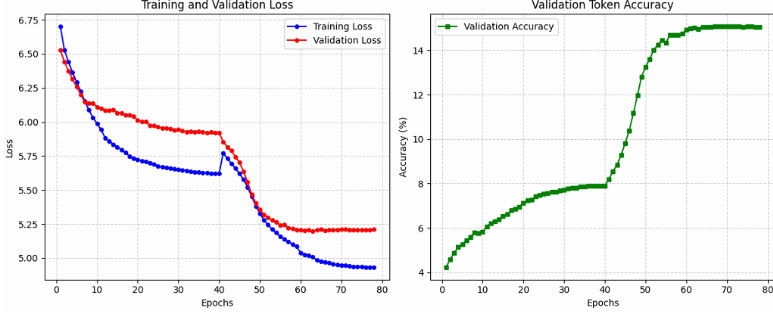

Training with all samples, and starting with

Embedding Dimension ($d_{model}$): 256

Attention Heads: 8

Encoder Layers: 2

Decoder layers: 2

Feed-forward Dimension ($d_{ff}$): 1024

we get the following loss curve, in which Model is overfitted at epoch 25 and best model checkpoint is saved using early stopping.
(Based on papers, it is common to consider Tolen Error rate instead of accuracy) The overfitting is mainly due to lack of data and large capacity.

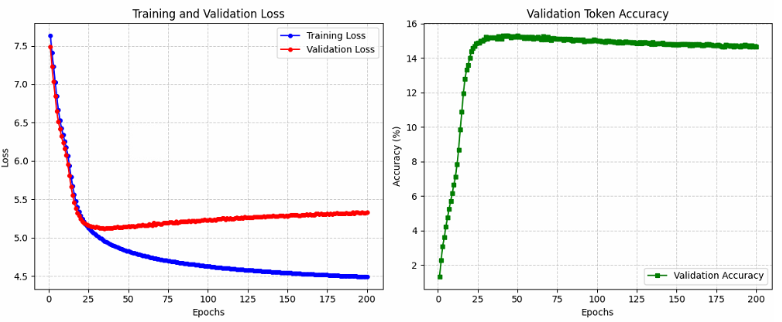

To address the overfitting caused by the limited dataset size (13k samples), several regularization techniques were employed:

**Data Augmentation:** Similar to time and frequency dropout in speech augmentation in seechbrain.augment, I applied random masking to the token embedding dimensions. This ensures the model encounters a unique variation of each sample in every epoch, effectively acting as an online data augmentation strategy.

 **Dropout**: The dropout rate was increased from 0.1 to 0.3 across all Transformer layers to enhance the model's generalization capabilities.

**Noam Learning Rate Scheduler:** I utilized the Noam scheduler with a warm-up phase(2000 steps, about 10 epochs). This allowed the model to stabilize its gradients during the early stages of training before gradually decaying the learning rate to fine-tune the separation performance.
I also switched to AdamW with weight decay of 0.01.

**Label smoothing ** is applied to prevent model from becoming overly confident in token prediction, by redistributing a small fraction of the probability mass from the "hard" ground-truth label to all other classes.

###Hyperparamter Tuning:
For our small dataset, it is better to use smaller model to avoid overfitting.    
Embedding Dimension ( dmodel ): 128    
Attention Heads: 4    
Encoder Layers: 2    
Decoder layers: 2    
Feed-forward Dimension ( dff ): 256   
As depicted below, validation loss does not increase as it did with previous larger model size. However, There is no improvment in final accuracy and convergence is slower.


{'num_layers': 2, 'd_model': 128, 'nhead': 4, 'dim_feedforward': 256, 'lr': 0.0008466068268482454, 'batch_size': 64}
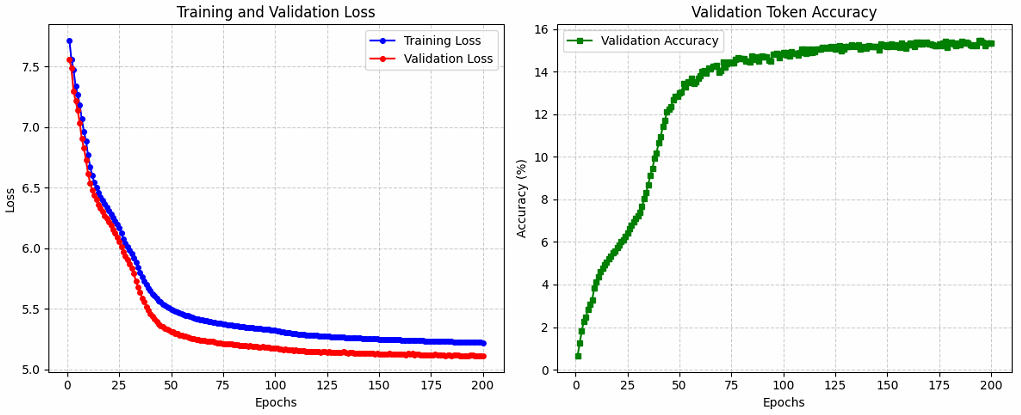

Experiments with higher model capacity showed a faster initial convergence and a rapid increase in training accuracy. However, this was accompanied by earlier and more severe overfitting, as the model began memorizing the limited training samples. To achieve a more robust and generalizable separation, I selected a more compact architecture which, despite a slightly slower convergence, maintained a better alignment between training and validation performance.

With increasing the sequence length to 3s, accuracy was decreased. we need to increase d_model for the model to learn long-term dependencies.

**The Problem of Speaker Ambiguity during Inference:** First, the assignment of $S_1$ and $S_2$ in the dataset was arbitrary. During Teacher Forcing, the model is forced to follow a specific sequence, but it lacks a "feature" or "reason" to distinguish why one speaker belongs to the first output stream versus the second. This leads to Inference Instability, where the model may start generating $S_1$ but switch to $S_2$ characteristics halfway through (Speaker Leakage). So we need to implement a Deterministic Ordering Rule during the data generation phase. **I changed it so S1 is always the one with larger SNR**. It is also possible Ordering based on the Onset Time (who speaks first) or find a difference between tokens.

After considering augmentation and changing total loss to sum of each speaker CE loss, we get the follownig result.

With teacher forcing on test set:
Test Loss: 11.4299 | Test Token Acc: 15.71%

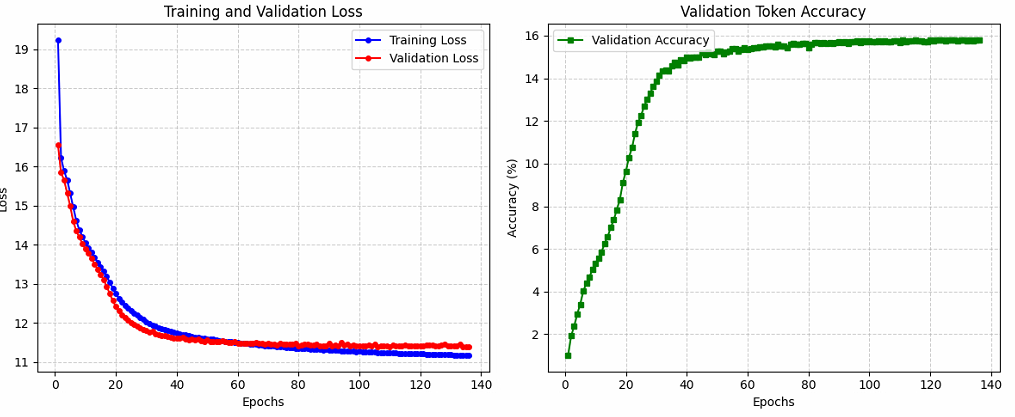

However the model does not show any performance in generating tokens during inference. In addition to data scarcity, this might be due to large number of classes. When trained model using the first codebook of EnCodec, the model had reached to 30% accuracy, probably due to smaller codebook size. Overall, this task requires massive training to show performance.

**Metric:**
I used SI-SDR (Scale-Invariant Signal-to-Distortion Ratio) for inference on test set to compare generated speaker signal to original one regardless of volume.

###Future works:
Based on focalcodec paper, I was trying to implement Conformer as encoder which takes the mix tokens and generate S1 tokens and S2 tokens in 2 heads using a linear layer of size 2*codebook and calculating CE on each chunk. In this framework PIT is necessary. Also it is suggested to use relative position embedding in attention layer and to use the pretrained focalcodec embeding layer instead of a learnable embedding layer.

Also we should consider generating more data in generation phase and takes all 2s windows or applying augmentation on audio/tokens.

There are other metrics to consider such as WER.


The model achieved a 15% Top-1 Accuracy under Teacher Forcing.  While Teacher Forcing provides the ground-truth token from the previous step as input, the relatively low accuracy suggests that the model is struggling to map the complex interleaved features of the mixture to the specific speaker latent space. This gap between validation accuracy and inference performance is a known as Exposure Bias, where the model fails to generalize when it has to rely on its own previous (and potentially erroneous) predictions during generation.
To reduce Exposure bias, we can apply Scheduled sampling.


##Refrences


1.   https://github.com/JorisCos/LibriMix
2.   H. Erdogan, S. Wisdom, X. Chang, Z. Borsos, M. Tagliasacchi, N. Zeghidour, and J. R. Hershey, "TokenSplit: Using Discrete Speech Representations for Direct, Refined, and Transcript-Conditioned Speech Separation and Recognition,"
3. Libera, Luca Della et al. “FocalCodec: Low-Bitrate Speech Coding via Focal Modulation Networks.” ArXiv abs/2502.04465 (2025)
4. https://github.com/facebookresearch/encodec

